<a href="https://colab.research.google.com/github/Gilanggg20/Tugas-Kecil/blob/main/Klasifikasi_Risiko_Kredit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BAGIAN 0: IMPORT LIBRARY**

In [1]:
!pip install -q xgboost lightgbm catboost streamlit joblib

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import streamlit as st

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 116.2 MB/s eta 0:00:00


# **BAGIAN 1: DATA UNDERSTANDING**

In [2]:
df = pd.read_csv('/content/credit_risk_dataset.csv')
print("Ukuran dataset:", df.shape)
print("\n5 data teratas:")
display(df.head())


Ukuran dataset: (32581, 12)

5 data teratas:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
print("\nInfo dataset:")
df.info()


Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [4]:
print("\nDeskripsi statistik:")
display(df.describe(include="all"))


Deskripsi statistik:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581,31686.000000,32581,32581,32581.000000,29465.000000,32581.000000,32581.000000,32581,32581.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,NaN,N,NaN
freq,NaN,NaN,16446,NaN,6453,10777,NaN,NaN,NaN,NaN,26836,NaN
mean,27.734600,6.607485e+04,NaN,4.789686,NaN,NaN,9589.371106,11.011695,0.218164,0.170203,NaN,5.804211
std,6.348078,6.198312e+04,NaN,4.142630,NaN,NaN,6322.086646,3.240459,0.413006,0.106782,NaN,4.055001
min,20.000000,4.000000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,0.000000,0.000000,NaN,2.000000
25%,23.000000,3.850000e+04,NaN,2.000000,NaN,NaN,5000.000000,7.900000,0.000000,0.090000,NaN,3.000000
50%,26.000000,5.500000e+04,NaN,4.000000,NaN,NaN,8000.000000,10.990000,0.000000,0.150000,NaN,4.000000
75%,30.000000,7.920000e+04,NaN,7.000000,NaN,NaN,12200.000000,13.470000,0.000000,0.230000,NaN,8.000000


In [5]:
# Distribusi awal target asli loan_grade
print("Distribusi awal loan_grade (jumlah):")
loan_grade_count = df["loan_grade"].value_counts().sort_index()
display(loan_grade_count)

print("Distribusi awal loan_grade (persentase):")
loan_grade_pct = (df["loan_grade"].value_counts(normalize=True).sort_index() * 100).round(2)
display(loan_grade_pct)

dist_awal = pd.DataFrame({
    "Jumlah": loan_grade_count,
    "Persentase (%)": loan_grade_pct
})
display(dist_awal)

Distribusi awal loan_grade (jumlah):


,count
loan_grade,
A,10777
B,10451
C,6458
D,3626
E,964
F,241
G,64


Distribusi awal loan_grade (persentase):


,proportion
loan_grade,
A,33.08
B,32.08
C,19.82
D,11.13
E,2.96
F,0.74
G,0.20


,Jumlah,Persentase (%)
loan_grade,,
A,10777,33.08
B,10451,32.08
C,6458,19.82
D,3626,11.13
E,964,2.96
F,241,0.74
G,64,0.20


# **BAGIAN 2: EXPLORATORY DATA ANALYSIS (EDA)**

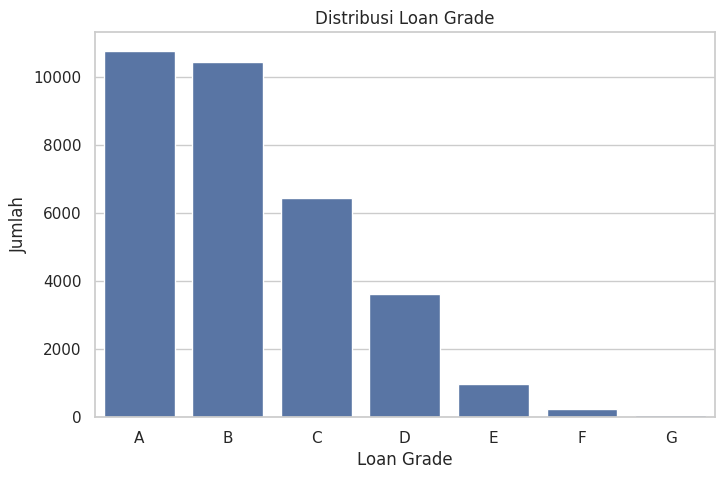

In [6]:
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="loan_grade", order=sorted(df["loan_grade"].dropna().unique()))
plt.title("Distribusi Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Jumlah")
plt.show()

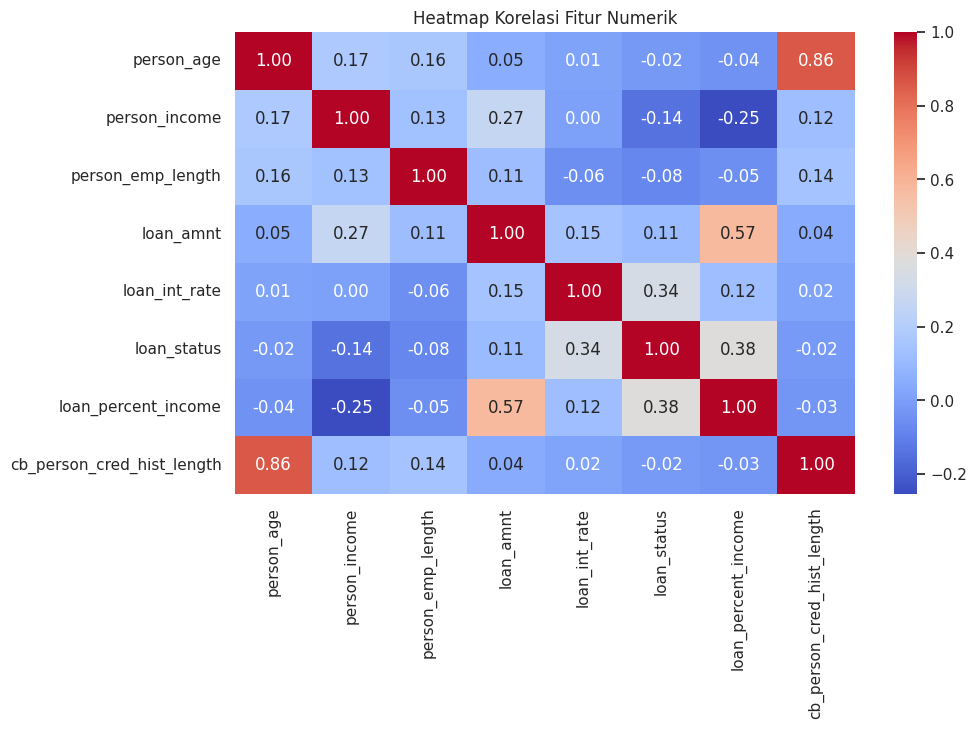

In [7]:
# Heatmap korelasi fitur numerik
numeric_cols_temp = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols_temp].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()

# **BAGIAN 3: DATA CLEANING**

In [8]:
df_clean = df.copy()

In [9]:
print("Missing values sebelum cleaning:")
missing_before = df_clean.isnull().sum()
display(missing_before[missing_before > 0].sort_values(ascending=False))

Missing values sebelum cleaning:


,0
loan_int_rate,3116
person_emp_length,895


In [10]:
# Pisahkan kolom numerik dan kategorikal
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_clean.select_dtypes(exclude=np.number).columns.tolist()

In [11]:
# Imputasi missing values
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values sesudah cleaning:")
missing_after = df_clean.isnull().sum()
display(missing_after[missing_after > 0].sort_values(ascending=False))

print("Total missing values sesudah cleaning:", df_clean.isnull().sum().sum())

Missing values sesudah cleaning:


,0


Total missing values sesudah cleaning: 0


In [12]:
# Kolom yang ingin dicek outlier-nya
outlier_cols = ["person_income", "loan_amnt", "loan_int_rate", "loan_percent_income"]

# Ambil hanya kolom yang benar-benar ada di dataset
available_outlier_cols = [col for col in outlier_cols if col in df_clean.columns]

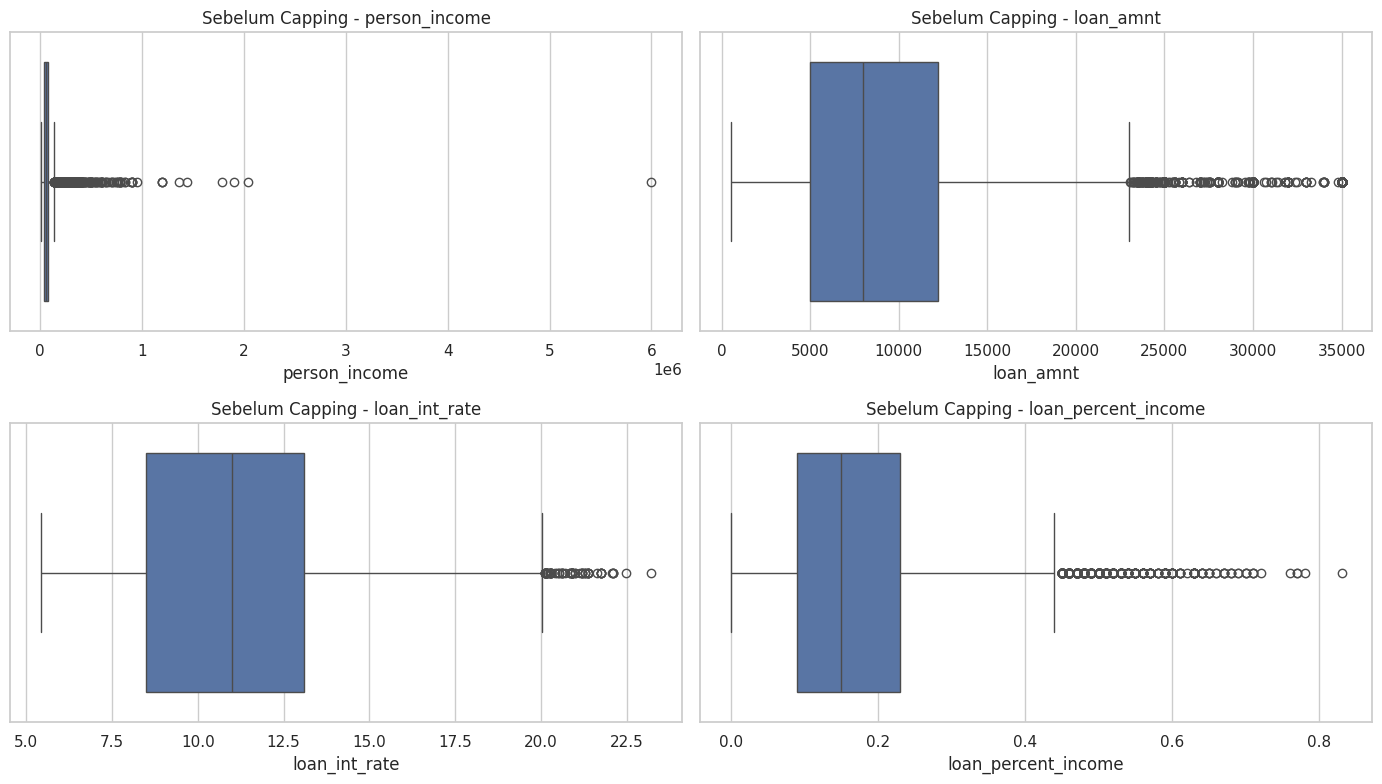

In [13]:
# Boxplot sebelum penanganan outlier
plt.figure(figsize=(14, 8))
for i, col in enumerate(available_outlier_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df_clean[col])
    plt.title(f"Sebelum Capping - {col}")
plt.tight_layout()
plt.show()

In [14]:
# Fungsi IQR capping / winsorizing ringan
def iqr_capping(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return np.clip(series, lower_bound, upper_bound)

for col in available_outlier_cols:
    df_clean[col] = iqr_capping(df_clean[col])

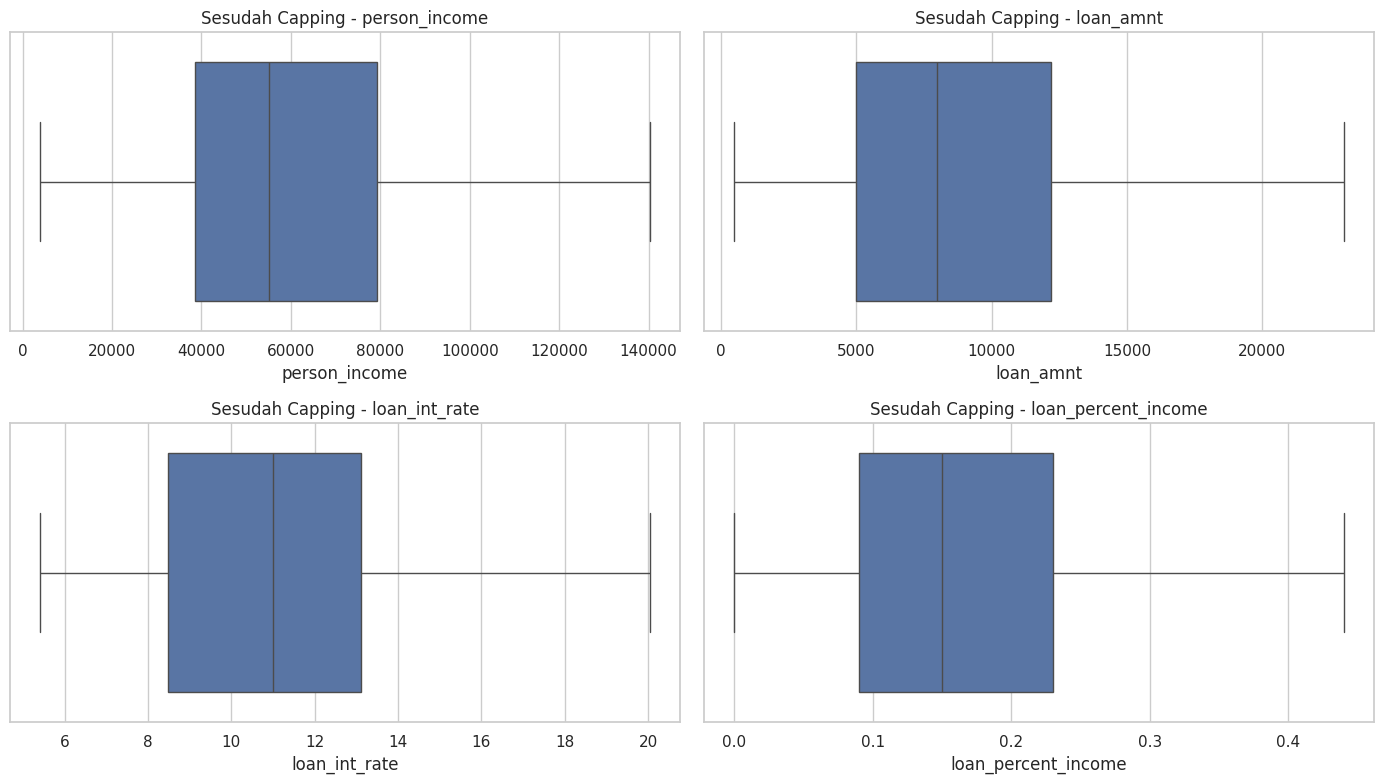

In [15]:
# Boxplot sesudah penanganan outlier
plt.figure(figsize=(14, 8))
for i, col in enumerate(available_outlier_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df_clean[col])
    plt.title(f"Sesudah Capping - {col}")
plt.tight_layout()
plt.show()

# **BAGIAN 4: FEATURE ENGINEERING**

In [16]:
df_model = df_clean.copy()

In [17]:
# Mapping loan_grade menjadi label risiko yang lebih komunikatif
risk_mapping = {
    "A": "Very Low Risk",
    "B": "Low Risk",
    "C": "Moderate Risk",
    "D": "High Risk",
    "E": "Very High Risk",
    "F": "Very High Risk",
    "G": "Very High Risk"
}

df_model["risk_level"] = df_model["loan_grade"].map(risk_mapping)

In [18]:
print("""
Penjelasan:
- loan_grade pada dataset digunakan sebagai representasi tingkat risiko kredit.
- Label diubah menjadi nama risiko yang lebih komunikatif agar lebih mudah dipahami saat presentasi dan deployment.
- Kelas E, F, dan G digabung menjadi 'Very High Risk' agar distribusi kelas lebih masuk akal.
- Pendekatan ini tetap sesuai data asli dan tidak membuat target sintetis.
""")


Penjelasan:
- loan_grade pada dataset digunakan sebagai representasi tingkat risiko kredit.
- Label diubah menjadi nama risiko yang lebih komunikatif agar lebih mudah dipahami saat presentasi dan deployment.
- Kelas E, F, dan G digabung menjadi 'Very High Risk' agar distribusi kelas lebih masuk akal.
- Pendekatan ini tetap sesuai data asli dan tidak membuat target sintetis.



In [19]:
print("Distribusi risk_level:")
display(df_model["risk_level"].value_counts())

Distribusi risk_level:


,count
risk_level,
Very Low Risk,10777
Low Risk,10451
Moderate Risk,6458
High Risk,3626
Very High Risk,1269


In [20]:
# Drop loan_grade agar tidak terjadi data leakage
# Karena loan_grade adalah sumber langsung pembentukan target risk_level
df_model = df_model.drop(columns=["loan_grade"])

print("""
Kolom loan_grade di-drop dari fitur untuk menghindari data leakage,
karena loan_grade digunakan langsung untuk membentuk target risk_level.
""")

display(df_model.head())


Kolom loan_grade di-drop dari fitur untuk menghindari data leakage,
karena loan_grade digunakan langsung untuk membentuk target risk_level.



,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,risk_level
0,22,59000,RENT,123.0,PERSONAL,23000,16.02,1,0.44,Y,3,High Risk
1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2,Low Risk
2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.44,N,3,Moderate Risk
3,23,65500,RENT,4.0,MEDICAL,23000,15.23,1,0.44,N,2,Moderate Risk
4,24,54400,RENT,8.0,MEDICAL,23000,14.27,1,0.44,Y,4,Moderate Risk


# **BAGIAN 5: DATA PREPROCESSING**

In [21]:
X = df_model.drop(columns=["risk_level"])
y = df_model["risk_level"]

In [22]:
print("Total jumlah data sebelum preprocessing:", len(df_model))
print("\nDistribusi kelas target sebelum preprocessing:")
display(y.value_counts())

Total jumlah data sebelum preprocessing: 32581

Distribusi kelas target sebelum preprocessing:


,count
risk_level,
Very Low Risk,10777
Low Risk,10451
Moderate Risk,6458
High Risk,3626
Very High Risk,1269


In [23]:
# Identifikasi fitur numerik dan kategorikal
num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Kolom numerik:")
print(num_features)

print("\nKolom kategorikal:")
print(cat_features)

Kolom numerik:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']

Kolom kategorikal:
['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']


In [24]:
# Pipeline preprocessing numerik
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline preprocessing kategorikal
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Gabungkan preprocessing numerik dan kategorikal
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

print("\nPreprocessing pipeline berhasil dibuat.")


Preprocessing pipeline berhasil dibuat.


# **BAGIAN 6: HANDLING IMBALANCED DATA**

In [25]:
balanced_df = df_model.copy()

In [26]:
print("Distribusi kelas sebelum undersampling:")
display(balanced_df["risk_level"].value_counts())

print("Total jumlah data sebelum undersampling:", len(balanced_df))

Distribusi kelas sebelum undersampling:


,count
risk_level,
Very Low Risk,10777
Low Risk,10451
Moderate Risk,6458
High Risk,3626
Very High Risk,1269


Total jumlah data sebelum undersampling: 32581


In [27]:
# Menentukan jumlah minimum dari seluruh kelas
min_class_size = balanced_df["risk_level"].value_counts().min()

In [28]:
# Undersampling mengikuti jumlah kelas paling sedikit
balanced_df = (
    balanced_df
    .groupby("risk_level", group_keys=False)
    .apply(lambda x: x.sample(n=min_class_size, random_state=42))
    .reset_index(drop=True)
)

print("Distribusi kelas sesudah undersampling:")
display(balanced_df["risk_level"].value_counts())

print("Total jumlah data sesudah undersampling:", len(balanced_df))

print("""
Undersampling dipilih karena:
- diminta menghindari banyak data dummy/sintetis,
- semua data balancing tetap berasal dari data asli,
- jumlah data tiap kelas dibuat seimbang mengikuti kelas yang paling sedikit.
""")

Distribusi kelas sesudah undersampling:


,count
risk_level,
High Risk,1269
Low Risk,1269
Moderate Risk,1269
Very High Risk,1269
Very Low Risk,1269


Total jumlah data sesudah undersampling: 6345

Undersampling dipilih karena:
- diminta menghindari banyak data dummy/sintetis,
- semua data balancing tetap berasal dari data asli,
- jumlah data tiap kelas dibuat seimbang mengikuti kelas yang paling sedikit.



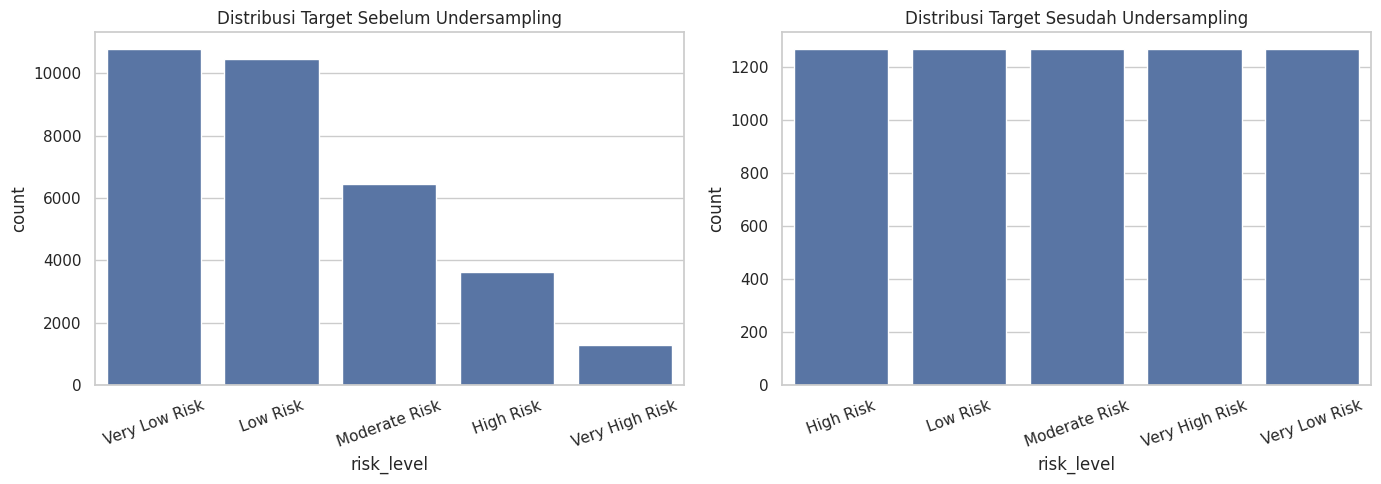

In [29]:
# Visualisasi distribusi target sebelum dan sesudah balancing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=df_model,
    x="risk_level",
    order=df_model["risk_level"].value_counts().index,
    ax=axes[0]
)
axes[0].set_title("Distribusi Target Sebelum Undersampling")
axes[0].tick_params(axis='x', rotation=20)

sns.countplot(
    data=balanced_df,
    x="risk_level",
    order=balanced_df["risk_level"].value_counts().index,
    ax=axes[1]
)
axes[1].set_title("Distribusi Target Sesudah Undersampling")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [30]:
# Data final setelah balancing
X_bal = balanced_df.drop(columns=["risk_level"])
y_bal = balanced_df["risk_level"]

# **BAGIAN 7: DATA SPLITTING**

In [31]:
split_scenarios = {
    "90:10": 0.10,
    "80:20": 0.20,
    "70:30": 0.30,
    "60:40": 0.40
}

split_data = {}

for split_name, test_size in split_scenarios.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_bal, y_bal,
        test_size=test_size,
        stratify=y_bal,
        random_state=42
    )

    split_data[split_name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print(f"\nSplit {split_name}")
    print("X_train:", X_train.shape, "| X_test:", X_test.shape)
    print("Distribusi y_train:")
    display(y_train.value_counts())
    print("Distribusi y_test:")
    display(y_test.value_counts())


Split 90:10
X_train: (5710, 11) | X_test: (635, 11)
Distribusi y_train:


,count
risk_level,
Very Low Risk,1142
Very High Risk,1142
High Risk,1142
Moderate Risk,1142
Low Risk,1142


Distribusi y_test:


,count
risk_level,
High Risk,127
Moderate Risk,127
Very High Risk,127
Very Low Risk,127
Low Risk,127



Split 80:20
X_train: (5076, 11) | X_test: (1269, 11)
Distribusi y_train:


...

,count
risk_level,
High Risk,381
Very High Risk,381
Moderate Risk,381
Very Low Risk,381
Low Risk,380



Split 60:40
X_train: (3807, 11) | X_test: (2538, 11)
Distribusi y_train:


,count
risk_level,
Low Risk,762
Very Low Risk,762
High Risk,761
Moderate Risk,761
Very High Risk,761


Distribusi y_test:


,count
risk_level,
Moderate Risk,508
Very High Risk,508
High Risk,508
Low Risk,507
Very Low Risk,507


# **BAGIAN 8: MODELING**

In [32]:
identity = lambda x: x

label_encoder = LabelEncoder()
label_encoder.fit(y_bal)

LabelEncoder()

In [33]:
base_models = {
    "CatBoost": {
        "estimator": CatBoostClassifier(
            random_state=42,
            iterations=300,
            depth=6,
            learning_rate=0.05,
            loss_function="MultiClass",
            verbose=0
        ),
        "target_transform": label_encoder.transform,
        "prediction_inverse_transform": label_encoder.inverse_transform
    },
    "XGBoost": {
        "estimator": XGBClassifier(
            random_state=42,
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            eval_metric="mlogloss",
            use_label_encoder=False
        ),
        "target_transform": label_encoder.transform,
        "prediction_inverse_transform": label_encoder.inverse_transform
    },
    "LightGBM": {
        "estimator": LGBMClassifier(
            random_state=42,
            n_estimators=200,
            learning_rate=0.05,
            num_leaves=31,
            class_weight=None
        ),
        "target_transform": identity,
        "prediction_inverse_transform": identity
    }
}

In [34]:
results = []
trained_models = {}

In [43]:
for split_name, data_dict in split_data.items():
    X_train = data_dict["X_train"]
    X_test = data_dict["X_test"]
    y_train = data_dict["y_train"]
    y_test = data_dict["y_test"]

    for model_name, model_config in base_models.items():
        print(f"\nTraining {model_name} pada split {split_name}")

        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", model_config["estimator"])
        ])

        y_train_ready = model_config["target_transform"](y_train)
        pipeline.fit(X_train, y_train_ready)

        y_pred_raw = pipeline.predict(X_test)
        y_pred_raw = np.array(y_pred_raw).reshape(-1)
        y_pred = model_config["prediction_inverse_transform"](y_pred_raw.astype(int)) \
            if model_name in ["CatBoost", "XGBoost"] else y_pred_raw

        predict_proba_fn = getattr(pipeline, "predict_proba", lambda X: None)
        y_proba = predict_proba_fn(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

        results.append({
            "Model": model_name,
            "Split": split_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1
        })

        trained_models[(model_name, split_name)] = {
            "pipeline": pipeline,
            "y_test": y_test,
            "y_pred": y_pred,
            "y_proba": y_proba
        }


Training CatBoost pada split 90:10

Training XGBoost pada split 90:10

Training LightGBM pada split 90:10
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000432 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 882
[LightGBM] [Info] Number of data points in the train set: 5710, number of used features: 19
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438

Training CatBoost pada split 80:20

Training XGBoost pada split 80:20

Training LightGBM pada split 80:20
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000375 seconds.
You can set `force_row_wise=true` to remove the overhead.
And

In [44]:
results_df = pd.DataFrame(results)
display(results_df.sort_values(by=["F1-Score", "Accuracy"], ascending=False))

,Model,Split,Accuracy,Precision,Recall,F1-Score
5,LightGBM,80:20,0.897557,0.898773,0.897557,0.897692
17,LightGBM,80:20,0.897557,0.898773,0.897557,0.897692
2,LightGBM,90:10,0.896063,0.897158,0.896063,0.896003
14,LightGBM,90:10,0.896063,0.897158,0.896063,0.896003
1,XGBoost,90:10,0.896063,0.898091,0.896063,0.895851
13,XGBoost,90:10,0.896063,0.898091,0.896063,0.895851
8,LightGBM,70:30,0.888655,0.889339,0.888655,0.888657
20,LightGBM,70:30,0.888655,0.889339,0.888655,0.888657
11,LightGBM,60:40,0.885343,0.885859,0.885343,0.885180
23,LightGBM,60:40,0.885343,0.885859,0.885343,0.885180


# **BAGIAN 9: HYPERPARAMETER TUNING**

In [45]:
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

X_train_tune = split_data["80:20"]["X_train"]
X_test_tune = split_data["80:20"]["X_test"]
y_train_tune = split_data["80:20"]["y_train"]
y_test_tune = split_data["80:20"]["y_test"]

In [46]:
label_encoder = LabelEncoder()
label_encoder.fit(y_bal)

identity = lambda x: x

In [47]:
tuning_configs = {
    "CatBoost": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", CatBoostClassifier(
                random_state=42,
                loss_function="MultiClass",
                verbose=0
            ))
        ]),
        "param_distributions": {
            "model__iterations": [100, 200, 300],
            "model__depth": [4, 6, 8],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__l2_leaf_reg": [1, 3, 5, 7]
        },
        "target_transform": label_encoder.transform,
        "prediction_inverse_transform": label_encoder.inverse_transform
    },

    "XGBoost": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", XGBClassifier(
                random_state=42,
                objective="multi:softprob",
                eval_metric="mlogloss",
                use_label_encoder=False
            ))
        ]),
        "param_distributions": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        },
        "target_transform": label_encoder.transform,
        "prediction_inverse_transform": label_encoder.inverse_transform
    },

    "LightGBM": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", LGBMClassifier(random_state=42))
        ]),
        "param_distributions": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__num_leaves": [15, 31, 63],
            "model__max_depth": [-1, 5, 10, 15],
            "model__min_child_samples": [10, 20, 30]
        },
        "target_transform": identity,
        "prediction_inverse_transform": identity
    }
}

In [48]:
tuning_results = []
best_tuned_models = {}

In [49]:
for model_name, config in tuning_configs.items():
    print(f"\n{'='*70}")
    print(f"TUNING {model_name}")
    print(f"{'='*70}")

    y_train_ready = config["target_transform"](y_train_tune)

    random_search = RandomizedSearchCV(
        estimator=config["pipeline"],
        param_distributions=config["param_distributions"],
        n_iter=10,
        scoring="f1_weighted",
        cv=cv_strategy,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train_tune, y_train_ready)

    best_pipeline = random_search.best_estimator_

    y_pred_raw = best_pipeline.predict(X_test_tune)
    y_pred_raw = np.array(y_pred_raw).reshape(-1)

    y_pred = config["prediction_inverse_transform"](y_pred_raw.astype(int)) \
        if model_name in ["CatBoost", "XGBoost"] else y_pred_raw

    acc = accuracy_score(y_test_tune, y_pred)
    prec = precision_score(y_test_tune, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test_tune, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test_tune, y_pred, average="weighted", zero_division=0)

    print("Best Parameters:")
    print(random_search.best_params_)
    print("Best CV Score:")
    print(random_search.best_score_)

    tuning_results.append({
        "Model": model_name,
        "Best Parameters": random_search.best_params_,
        "Best CV Score": random_search.best_score_,
        "Test Accuracy": acc,
        "Test Precision": prec,
        "Test Recall": rec,
        "Test F1-Score": f1
    })

    best_tuned_models[model_name] = {
        "best_estimator": best_pipeline,
        "best_params": random_search.best_params_,
        "best_cv_score": random_search.best_score_,
        "y_test": y_test_tune,
        "y_pred": y_pred
    }


TUNING CatBoost
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'model__learning_rate': 0.1, 'model__l2_leaf_reg': 1, 'model__iterations': 300, 'model__depth': 6}
Best CV Score:
0.8415934717092363

TUNING XGBoost
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}
Best CV Score:
0.8550567632519005

TUNING LightGBM
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000600 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 882
[LightGBM] [Info] Number of data points in the train set: 5076, number of used features: 20
[LightGBM] [Info] Start training from score -1.609635
[LightGBM] [Info] Star

In [50]:
tuning_results_df = pd.DataFrame(tuning_results)
display(tuning_results_df)

,Model,Best Parameters,Best CV Score,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,CatBoost,"{'model__learning_rate': 0.1, 'model__l2_leaf_...",0.841593,0.884949,0.887444,0.884949,0.884992
1,XGBoost,"{'model__subsample': 1.0, 'model__n_estimators...",0.855057,0.880221,0.880905,0.880221,0.880053
2,LightGBM,"{'model__num_leaves': 31, 'model__n_estimators...",0.875754,0.903861,0.905715,0.903861,0.904025


# **BAGIAN 10: COST-SENSITIVE LEARNING**

In [57]:
#Setup Helper, Label Encoder, dan Class Weight

identity = lambda x: x

label_encoder = LabelEncoder()
label_encoder.fit(y_bal)

class_weight_dict = {
    "Very Low Risk": 1.0,
    "Low Risk": 1.0,
    "Moderate Risk": 1.0,
    "High Risk": 1.2,
    "Very High Risk": 1.3
}

encoded_class_weight_dict = {
    label_encoder.transform([label])[0]: weight
    for label, weight in class_weight_dict.items()
}

In [58]:
#Ambil Data Split 80:20 untuk Cost-Sensitive Learning

X_train_cs = split_data["80:20"]["X_train"]
X_test_cs = split_data["80:20"]["X_test"]
y_train_cs = split_data["80:20"]["y_train"]
y_test_cs = split_data["80:20"]["y_test"]

In [59]:
#Definisi Model Cost-Sensitive

cost_sensitive_models = {
    "CatBoost - Cost Sensitive": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", CatBoostClassifier(
                random_state=42,
                iterations=300,
                depth=6,
                learning_rate=0.05,
                loss_function="MultiClass",
                class_weights=encoded_class_weight_dict,
                verbose=0
            ))
        ]),
        "target_transform": label_encoder.transform,
        "prediction_inverse_transform": label_encoder.inverse_transform,
        "fit_params": {}
    },

    "XGBoost - Cost Sensitive": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", XGBClassifier(
                random_state=42,
                n_estimators=200,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                eval_metric="mlogloss",
                use_label_encoder=False
            ))
        ]),
        "target_transform": label_encoder.transform,
        "prediction_inverse_transform": label_encoder.inverse_transform,
        "fit_params": {
            "model__sample_weight": y_train_cs.map(class_weight_dict).values
        }
    },

    "LightGBM - Cost Sensitive": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", LGBMClassifier(
                random_state=42,
                n_estimators=200,
                learning_rate=0.05,
                num_leaves=31,
                class_weight=class_weight_dict
            ))
        ]),
        "target_transform": identity,
        "prediction_inverse_transform": identity,
        "fit_params": {}
    }
}

In [60]:
#Inisialisasi Penampung Hasil

cost_sensitive_results = []
cost_sensitive_trained_models = {}

In [61]:
#Training dan Evaluasi Cost-Sensitive Model

for model_name, model_config in cost_sensitive_models.items():
    print(f"\n{'='*70}")
    print(f"TRAINING {model_name}")
    print(f"{'='*70}")

    pipeline = model_config["pipeline"]

    y_train_ready = model_config["target_transform"](y_train_cs)
    pipeline.fit(X_train_cs, y_train_ready, **model_config["fit_params"])

    y_pred_raw = pipeline.predict(X_test_cs)
    y_pred_raw = np.array(y_pred_raw).reshape(-1)
    y_pred = model_config["prediction_inverse_transform"](y_pred_raw)

    predict_proba_fn = getattr(pipeline, "predict_proba", lambda X: None)
    y_proba = predict_proba_fn(X_test_cs)

    acc = accuracy_score(y_test_cs, y_pred)
    prec = precision_score(y_test_cs, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test_cs, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test_cs, y_pred, average="weighted", zero_division=0)

    cost_sensitive_results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

    cost_sensitive_trained_models[model_name] = {
        "pipeline": pipeline,
        "y_test": y_test_cs,
        "y_pred": y_pred,
        "y_proba": y_proba
    }


TRAINING CatBoost - Cost Sensitive

TRAINING XGBoost - Cost Sensitive

TRAINING LightGBM - Cost Sensitive
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000365 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 880
[LightGBM] [Info] Number of data points in the train set: 5076, number of used features: 19
[LightGBM] [Info] Start training from score -1.522606
[LightGBM] [Info] Start training from score -1.703942
[LightGBM] [Info] Start training from score -1.704927
[LightGBM] [Info] Start training from score -1.442563
[LightGBM] [Info] Start training from score -1.704927


In [62]:
#Tampilkan Hasil Akhir Cost-Sensitive Learning

cost_sensitive_results_df = pd.DataFrame(cost_sensitive_results)
display(cost_sensitive_results_df.sort_values(by=["F1-Score", "Accuracy"], ascending=False))

,Model,Accuracy,Precision,Recall,F1-Score
2,LightGBM - Cost Sensitive,0.895981,0.896540,0.895981,0.896044
1,XGBoost - Cost Sensitive,0.880221,0.881443,0.880221,0.880395
0,CatBoost - Cost Sensitive,0.851064,0.855380,0.851064,0.851313


# **BAGIAN 11: EVALUATION**

In [63]:
# Ambil model terbaik dari hasil tuning
best_tuned_model_name = tuning_results_df.sort_values(
    by=["Test F1-Score", "Test Accuracy"],
    ascending=False
).iloc[0]["Model"]

print("Model terbaik hasil tuning:", best_tuned_model_name)

best_model_info = best_tuned_models[best_tuned_model_name]
best_model_pipeline = best_model_info["best_estimator"]
y_test_best = best_model_info["y_test"]
y_pred_best = best_model_info["y_pred"]

Model terbaik hasil tuning: LightGBM


In [66]:
# =========================
# METRIK EVALUASI UTAMA
# =========================
acc = accuracy_score(y_test_best, y_pred_best)
prec = precision_score(y_test_best, y_pred_best, average="weighted", zero_division=0)
rec = recall_score(y_test_best, y_pred_best, average="weighted", zero_division=0)
f1 = f1_score(y_test_best, y_pred_best, average="weighted", zero_division=0)

print("\nHasil Evaluasi Model Terbaik")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")


Hasil Evaluasi Model Terbaik
Accuracy : 0.9039
Precision: 0.9057
Recall   : 0.9039
F1-Score : 0.9040


In [67]:
# =========================
# CLASSIFICATION REPORT
# =========================
print("\nClassification Report:")
print(classification_report(y_test_best, y_pred_best, zero_division=0))


Classification Report:
                precision    recall  f1-score   support

     High Risk       0.88      0.90      0.89       254
      Low Risk       0.86      0.94      0.89       253
 Moderate Risk       0.90      0.91      0.91       254
Very High Risk       0.93      0.86      0.89       254
 Very Low Risk       0.96      0.91      0.94       254

      accuracy                           0.90      1269
     macro avg       0.91      0.90      0.90      1269
  weighted avg       0.91      0.90      0.90      1269



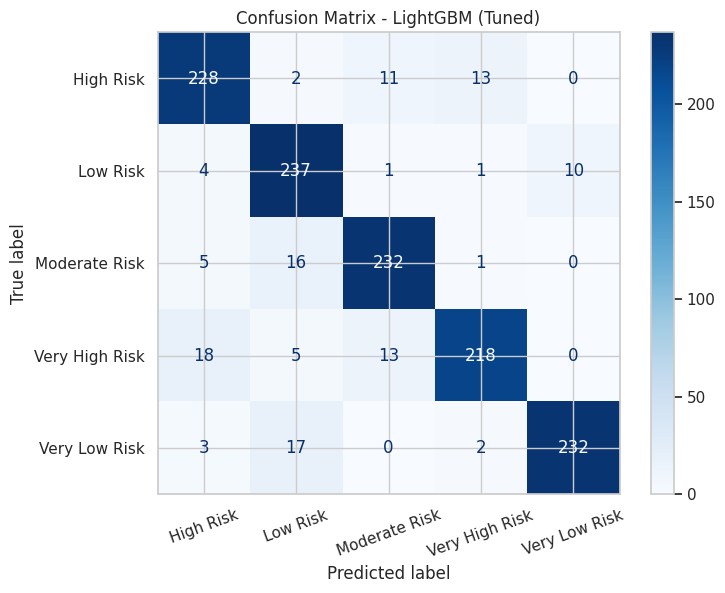

In [68]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

class_labels = sorted(y_bal.unique())

cm = confusion_matrix(y_test_best, y_pred_best, labels=class_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", ax=ax, xticks_rotation=20)
plt.title(f"Confusion Matrix - {best_tuned_model_name} (Tuned)")
plt.show()

In [70]:
# ============================================================
# CROSS VALIDATION
# Digunakan untuk mengecek kestabilan performa model
# ============================================================

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    estimator=best_model_pipeline,
    X=X_bal,
    y=y_bal,
    cv=cv_strategy,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Cross-validation F1-weighted scores:", cv_scores)
print("Rata-rata CV F1-weighted:", cv_scores.mean())
print("Standar deviasi CV:", cv_scores.std())

Cross-validation F1-weighted scores: [0.87782119 0.87963605 0.89168154]
Rata-rata CV F1-weighted: 0.8830462590807967
Standar deviasi CV: 0.00615085358245061


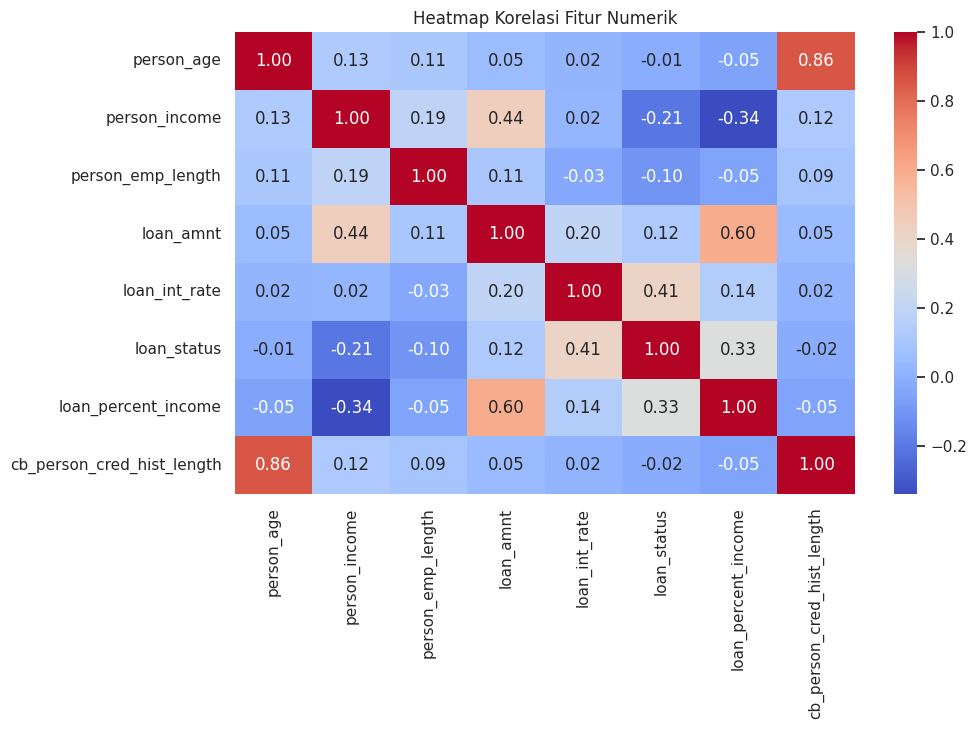

In [71]:
# ============================================================
# HEATMAP KORELASI FITUR NUMERIK
# ============================================================

numeric_corr_cols = X_bal.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 6))
sns.heatmap(
    X_bal[numeric_corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()

Top 15 Feature Importance:


,Feature,Importance
4,num__loan_int_rate,13254
1,num__person_income,6671
3,num__loan_amnt,4856
6,num__loan_percent_income,4276
0,num__person_age,3827
2,num__person_emp_length,3557
7,num__cb_person_cred_hist_length,2258
5,num__loan_status,972
18,cat__cb_person_default_on_file_N,721
17,cat__loan_intent_VENTURE,662


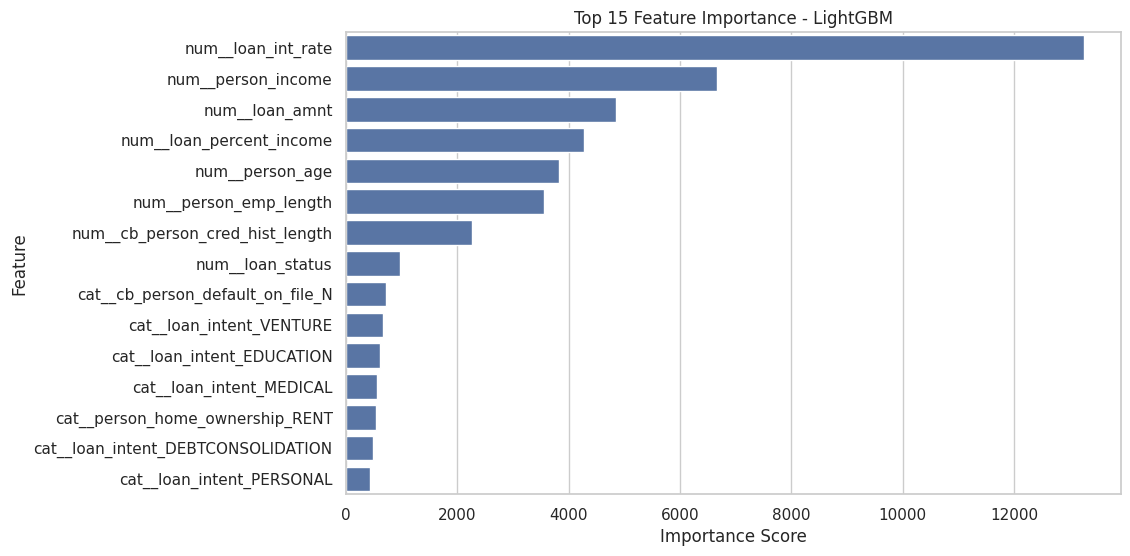

In [73]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

fitted_preprocessor = best_model_pipeline.named_steps["preprocessor"]
fitted_model = best_model_pipeline.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()
feature_importances = fitted_model.feature_importances_

fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

print("Top 15 Feature Importance:")
display(fi_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df.head(15), x="Importance", y="Feature")
plt.title(f"Top 15 Feature Importance - {best_tuned_model_name}")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# **BAGIAN 12: PERBANDINGAN MODEL**

In [74]:
# =========================
# 1. RATA-RATA BASELINE
# =========================
baseline_summary = (
    results_df.groupby("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]]
    .mean()
    .reset_index()
)

baseline_summary.columns = [
    "Model",
    "Baseline Accuracy",
    "Baseline Precision",
    "Baseline Recall",
    "Baseline F1-Score"
]


In [75]:
# =========================
# 2. HASIL TUNING
# =========================
tuning_summary = tuning_results_df[[
    "Model",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1-Score"
]].copy()

tuning_summary.columns = [
    "Model",
    "Tuned Accuracy",
    "Tuned Precision",
    "Tuned Recall",
    "Tuned F1-Score"
]

In [76]:
# =========================
# 3. HASIL COST-SENSITIVE
# =========================
cost_summary = cost_sensitive_results_df.copy()

cost_summary.columns = [
    "Model",
    "Cost Accuracy",
    "Cost Precision",
    "Cost Recall",
    "Cost F1-Score"
]

In [77]:
# Samakan nama model supaya bisa digabung
cost_summary["Model"] = cost_summary["Model"].replace({
    "CatBoost - Cost Sensitive": "CatBoost",
    "XGBoost - Cost Sensitive": "XGBoost",
    "LightGBM - Cost Sensitive": "LightGBM"
})

In [78]:
# =========================
# 4. GABUNGKAN SEMUA
# =========================
comparison_df = baseline_summary.merge(tuning_summary, on="Model", how="inner")
comparison_df = comparison_df.merge(cost_summary, on="Model", how="inner")

print("Perbandingan Model (Baseline vs Tuning vs Cost-Sensitive):")
display(comparison_df.sort_values(by="Tuned F1-Score", ascending=False))

Perbandingan Model (Baseline vs Tuning vs Cost-Sensitive):


,Model,Baseline Accuracy,Baseline Precision,Baseline Recall,Baseline F1-Score,Tuned Accuracy,Tuned Precision,Tuned Recall,Tuned F1-Score,Cost Accuracy,Cost Precision,Cost Recall,Cost F1-Score
1,LightGBM,0.891905,0.892782,0.891905,0.891883,0.903861,0.905715,0.903861,0.904025,0.895981,0.896540,0.895981,0.896044
0,CatBoost,0.858290,0.862653,0.858290,0.858093,0.884949,0.887444,0.884949,0.884992,0.851064,0.855380,0.851064,0.851313
2,XGBoost,0.880939,0.882141,0.880939,0.880732,0.880221,0.880905,0.880221,0.880053,0.880221,0.881443,0.880221,0.880395


# **BAGIAN 13: SIMPAN MODEL**

In [79]:
import os
import pickle

# Menentukan model terbaik berdasarkan hasil tuning
best_model_row = comparison_df.sort_values(
    by=["Tuned F1-Score", "Tuned Accuracy"],
    ascending=False
).iloc[0]

best_model_name = best_model_row["Model"]
best_model_pipeline = best_tuned_models[best_model_name]["best_estimator"]

print("Model terbaik yang akan disimpan:", best_model_name)

# Membuat folder models
os.makedirs("models", exist_ok=True)

# Simpan model utama
with open("models/best_model.pkl", "wb") as f:
    pickle.dump(best_model_pipeline, f)

Model terbaik yang akan disimpan: LightGBM


In [80]:
# Simpan metadata
model_metadata = {
    "best_model_name": best_model_name,
    "feature_columns": X_bal.columns.tolist(),
    "num_features": num_features,
    "cat_features": cat_features,
    "class_labels": sorted(y_bal.unique()),
    "label_encoder": label_encoder
}

with open("models/model_metadata.pkl", "wb") as f:
    pickle.dump(model_metadata, f)

print("Model berhasil disimpan:")
print("- models/best_model.pkl")
print("- models/model_metadata.pkl")

Model berhasil disimpan:
- models/best_model.pkl
- models/model_metadata.pkl


In [81]:
# ============================================================
# VERIFIKASI FILE PKL
# ============================================================

import pickle

with open("models/best_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

with open("models/model_metadata.pkl", "rb") as f:
    loaded_metadata = pickle.load(f)

print("Model berhasil dimuat kembali.")
print("Nama model terbaik :", loaded_metadata["best_model_name"])
print("Jumlah fitur       :", len(loaded_metadata["feature_columns"]))
print("Fitur numerik      :", loaded_metadata["num_features"])
print("Fitur kategorikal  :", loaded_metadata["cat_features"])
print("Label kelas        :", loaded_metadata["class_labels"])

Model berhasil dimuat kembali.
Nama model terbaik : LightGBM
Jumlah fitur       : 11
Fitur numerik      : ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']
Fitur kategorikal  : ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']
Label kelas        : ['High Risk', 'Low Risk', 'Moderate Risk', 'Very High Risk', 'Very Low Risk']


# **BAGIAN 14: INFERENCE / PREDIKSI DATA BARU**

In [82]:
import pickle
import pandas as pd

with open("models/best_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

with open("models/model_metadata.pkl", "rb") as f:
    loaded_metadata = pickle.load(f)

feature_columns = loaded_metadata["feature_columns"]

def predict_and_display(model, input_df, title):
    input_df = input_df.reindex(columns=feature_columns)

    predictions = model.predict(input_df)
    probabilities = model.predict_proba(input_df)

    result_df = input_df.copy()
    result_df["Predicted Risk Level"] = predictions

    probability_df = pd.DataFrame(
        probabilities,
        columns=model.named_steps["model"].classes_
    )

    print(title)
    display(result_df)
    print("Probabilitas prediksi:")
    display(probability_df)

In [83]:
single_input = X_bal.iloc[[0]].copy()
single_input.loc[single_input.index[0], "person_income"] = 45000000
single_input.loc[single_input.index[0], "loan_amnt"] = 15000000
single_input.loc[single_input.index[0], "loan_int_rate"] = 12.5
single_input.loc[single_input.index[0], "loan_percent_income"] = 0.30

predict_and_display(loaded_model, single_input, "Hasil prediksi 1 data baru:")

Hasil prediksi 1 data baru:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Predicted Risk Level
0,26,45000000,RENT,0.0,PERSONAL,15000000,12.5,1,0.3,Y,2,High Risk


Probabilitas prediksi:


,High Risk,Low Risk,Moderate Risk,Very High Risk,Very Low Risk
0,0.565011,0.001341,0.395049,0.038563,0.000036


In [84]:
# beberapa data baru
multi_input = X_bal.iloc[:3].copy()
multi_input.loc[multi_input.index[0], "person_income"] = 35000000
multi_input.loc[multi_input.index[1], "person_income"] = 70000000
multi_input.loc[multi_input.index[2], "person_income"] = 120000000

predict_and_display(loaded_model, multi_input, "Hasil prediksi beberapa data baru:")

Hasil prediksi beberapa data baru:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Predicted Risk Level
0,26,35000000,RENT,0.0,PERSONAL,5000,15.99,1,0.13,Y,2,High Risk
1,22,70000000,RENT,1.0,MEDICAL,23000,15.95,1,0.35,N,4,High Risk
2,27,120000000,RENT,0.0,HOMEIMPROVEMENT,6000,18.07,1,0.28,N,7,Very High Risk


Probabilitas prediksi:


,High Risk,Low Risk,Moderate Risk,Very High Risk,Very Low Risk
0,0.990457,0.000003,0.000070,0.009468,0.000003
1,0.639681,0.000126,0.000470,0.359706,0.000017
2,0.031608,0.000024,0.000054,0.968308,0.000006


# **BAGIAN 15: MODEL DEPLOYMENT**

In [86]:
!pip install -q streamlit pyngrok

In [87]:
from pyngrok import ngrok

ngrok.set_auth_token("3AiK1iSXnBJ3x8LTEnf91DKJ2Z6_2KJjSBzrq2RfouzZFMCGb")

In [91]:
from google.colab import files
uploaded = files.upload()

Saving best_model.pkl to best_model.pkl
Saving model_metadata.pkl to model_metadata.pkl


In [95]:
%%writefile app.py
import pickle
import pandas as pd
import streamlit as st

# ============================================================
# KONFIGURASI HALAMAN
# ============================================================
st.set_page_config(
    page_title="Prediksi Risiko Kredit",
    page_icon="💳",
    layout="centered"
)

# ============================================================
# LOAD MODEL DAN METADATA
# ============================================================
with open("best_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("model_metadata.pkl", "rb") as f:
    metadata = pickle.load(f)

feature_columns = metadata["feature_columns"]
best_model_name = metadata["best_model_name"]

# ============================================================
# FUNGSI BANTU
# ============================================================
risk_descriptions = {
    "Very Low Risk": "Risiko kredit sangat rendah. Calon peminjam tergolong sangat aman.",
    "Low Risk": "Risiko kredit rendah. Kemungkinan gagal bayar relatif kecil.",
    "Moderate Risk": "Risiko kredit sedang. Perlu pertimbangan lebih lanjut sebelum persetujuan.",
    "High Risk": "Risiko kredit tinggi. Perlu perhatian lebih dalam proses analisis kredit.",
    "Very High Risk": "Risiko kredit sangat tinggi. Potensi gagal bayar besar dan perlu kehati-hatian."
}

risk_colors = {
    "Very Low Risk": "#16a34a",
    "Low Risk": "#22c55e",
    "Moderate Risk": "#eab308",
    "High Risk": "#f97316",
    "Very High Risk": "#dc2626"
}

def build_prediction_card(prediction: str):
    color = risk_colors.get(prediction, "#2563eb")
    description = risk_descriptions.get(prediction, "Tidak ada deskripsi.")
    card_html = f"""
    <div style="
        background-color: {color}20;
        border-left: 8px solid {color};
        padding: 18px;
        border-radius: 12px;
        margin-top: 10px;
        margin-bottom: 15px;
    ">
        <h3 style="margin: 0; color: {color};">Hasil Prediksi: {prediction}</h3>
        <p style="margin-top: 8px; font-size: 15px;">{description}</p>
    </div>
    """
    return card_html

# ============================================================
# HEADER
# ============================================================
st.title("💳 Prediksi Risiko Kredit")
st.markdown("### Sistem Prediksi Risiko Kredit Berbasis Machine Learning")
st.caption(f"Model yang digunakan: {best_model_name}")

st.write(
    """
Aplikasi ini digunakan untuk memprediksi tingkat risiko kredit calon peminjam
berdasarkan data finansial yang dimasukkan pengguna.
"""
)

# ============================================================
# FORM INPUT
# ============================================================
st.subheader("Input Data Calon Peminjam")

with st.form("credit_form"):
    col1, col2 = st.columns(2)

    with col1:
        person_age = st.number_input("Usia", min_value=18, max_value=100, value=30)
        person_income = st.number_input("Pendapatan Tahunan", min_value=0.0, value=50000000.0, step=1000000.0)
        person_home_ownership = st.selectbox(
            "Status Kepemilikan Rumah",
            ["RENT", "OWN", "MORTGAGE", "OTHER"]
        )
        person_emp_length = st.number_input("Lama Bekerja (tahun)", min_value=0.0, value=5.0, step=1.0)
        loan_intent = st.selectbox(
            "Tujuan Pinjaman",
            ["PERSONAL", "EDUCATION", "MEDICAL", "VENTURE", "HOMEIMPROVEMENT", "DEBTCONSOLIDATION"]
        )

    with col2:
        loan_amnt = st.number_input("Jumlah Pinjaman", min_value=0.0, value=10000000.0, step=500000.0)
        loan_int_rate = st.number_input("Suku Bunga Pinjaman", min_value=0.0, value=12.0, step=0.1)
        loan_percent_income = st.number_input("Rasio Pinjaman terhadap Pendapatan", min_value=0.0, value=0.25, step=0.01)
        cb_person_default_on_file = st.selectbox("Riwayat Default Sebelumnya", ["Y", "N"])
        cb_person_cred_hist_length = st.number_input("Lama Riwayat Kredit (tahun)", min_value=0.0, value=5.0, step=1.0)

    submitted = st.form_submit_button("🔍 Prediksi Risiko")

# ============================================================
# PREDIKSI
# ============================================================
if submitted:
    input_data = pd.DataFrame([{
        "person_age": person_age,
        "person_income": person_income,
        "person_home_ownership": person_home_ownership,
        "person_emp_length": person_emp_length,
        "loan_intent": loan_intent,
        "loan_amnt": loan_amnt,
        "loan_int_rate": loan_int_rate,
        "loan_percent_income": loan_percent_income,
        "cb_person_default_on_file": cb_person_default_on_file,
        "cb_person_cred_hist_length": cb_person_cred_hist_length
    }])

    input_data = input_data.reindex(columns=feature_columns)

    prediction = model.predict(input_data)[0]
    probabilities = model.predict_proba(input_data)[0]
    class_names = model.named_steps["model"].classes_

    # Hasil utama
    st.markdown(build_prediction_card(prediction), unsafe_allow_html=True)

    # Ringkasan input
    with st.expander("Lihat Ringkasan Input"):
        st.dataframe(input_data, use_container_width=True)

    # Probabilitas
    probability_df = pd.DataFrame({
        "Risk Level": class_names,
        "Probability": probabilities
    }).sort_values(by="Probability", ascending=False)

    st.subheader("📊 Probabilitas Prediksi")
    st.dataframe(
        probability_df.assign(
            Probability=lambda df: (df["Probability"] * 100).round(2).astype(str) + "%"
        ),
        use_container_width=True
    )

    st.subheader("Visualisasi Keyakinan Model")
    for _, row in probability_df.iterrows():
        label = row["Risk Level"]
        prob = float(row["Probability"])
        st.write(f"**{label}** — {prob * 100:.2f}%")
        st.progress(prob)

    # Insight singkat
    top_probability = probability_df.iloc[0]["Probability"] * 100
    st.info(
        f"Model paling yakin bahwa calon peminjam berada pada kategori **{prediction}** "
        f"dengan tingkat keyakinan sekitar **{top_probability:.2f}%**."
    )

Overwriting app.py


In [93]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

In [94]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://samara-epigraphic-unostentatiously.ngrok-free.dev" -> "http://localhost:8501"
